**Task 1: Dataset Understanding**

In [102]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
#loading dataset
df = pd.read_csv('/content/customer_churn_nn.csv')

In [104]:
# Displaying first 11 rows of dataset
df.head(11)

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0
5,CUST0006,North,Premium,One-year,Wallet,13,1058.22,13,1,1,157.49,8.3,115,10,0,1,0
6,CUST0007,Central,Standard,Two-year,Debit Card,38,765.73,18,2,0,119.12,7.1,10,0,1,1,0
7,CUST0008,South,Basic,Month-to-month,UPI,16,327.42,11,5,8,32.46,6.9,99,0,0,0,0
8,CUST0009,South,Premium,Month-to-month,Debit Card,19,1050.49,22,0,2,136.53,6.0,7,20,0,0,0
9,CUST0010,Central,Standard,One-year,Credit Card,20,732.89,14,3,1,115.10,6.4,0,20,0,0,0


In [105]:
#number of rows and columns
df.shape

(2000, 17)

In [106]:
#column names
df.columns

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

In [107]:
#data types
df.dtypes

,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [108]:
#missing values
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [109]:
# statistical summary of data
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


/tmp/ipykernel_827/3997322382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df,


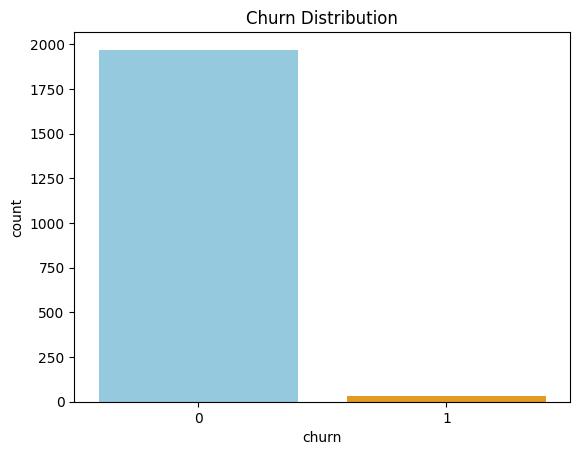

In [110]:
# Visualizing the distribution of the target variable 'churn'
# This helps us understand how many customers stayed vs left

sns.countplot(x='churn', data=df,
palette=['skyblue', 'orange'])

# Adding title to the graph
plt.title("Churn Distribution")

# Displaying the plot
plt.show()

**OBSERVATION**

Dataset contains 2000 rows and 17 columns.

The target variable is 'churn', which represents whether a customer left the service or not-Observation:

The churn distribution chart shows that the dataset is highly imbalanced.
Most customers belong to class 0, which represents customers who did not churn, while only a very small number of customers belong to class 1, representing customers who churned.

This indicates that the majority of customers stayed with the company. Due to this imbalance, the neural network model may become biased toward predicting the majority class. Therefore, evaluation metrics such as confusion matrix, precision, recall, and F1-score will be important for proper model evaluation.

Dataset contains both categorical and numerical features.

No major missing values were found in the dataset.

**Task 2: Data Preprocessing**

In [111]:
# Importing required libraries for preprocessing

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [112]:
# Checking missing values in each column

df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [113]:
# Checking dataset column data types

df.dtypes

,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [114]:
# Removing missing values if present

df = df.dropna()

In [115]:
# Creating LabelEncoder object

le = LabelEncoder()

# Encoding categorical columns into numerical values

df['region'] = le.fit_transform(df['region'])

df['plan_type'] = le.fit_transform(df['plan_type'])

df['contract_type'] = le.fit_transform(df['contract_type'])

df['payment_method'] = le.fit_transform(df['payment_method'])

In [116]:
# Removing customer_id column because it is not useful for prediction

df = df.drop('customer_id', axis=1)

In [117]:
# Separating input features and target variable
# X contains input features
# y contains target variable

X = df.drop('churn', axis=1)

y = df['churn']

In [118]:
# Creating StandardScaler object

scaler = StandardScaler()

# Scaling input features

X = scaler.fit_transform(X)

In [119]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [120]:
# Checking shapes of training and testing datasets

print("Training Features Shape:", X_train.shape)

print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)

print("Testing Target Shape:", y_test.shape)

Training Features Shape: (1600, 15)
Testing Features Shape: (400, 15)
Training Target Shape: (1600,)
Testing Target Shape: (400,)


**Observation**:

The dataset was preprocessed successfully for neural network training. Missing values were checked and handled using dropna(). Categorical columns such as region, plan_type, contract_type, and payment_method were encoded into numerical format using Label Encoding. The customer_id column was removed because it does not contribute to prediction. Numerical features were standardized using StandardScaler to improve model performance. Finally, the dataset was split into training and testing sets using an 80:20 ratio.

**Task 3: Neural Network Model Building**

In [121]:
# Importing required libraries for neural network model building

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [122]:
# Creating Sequential neural network model

model = Sequential()

# Adding input layer and first hidden layer
# Dense(16) means 16 neurons
# ReLU is the activation function

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Adding second hidden layer

model.add(Dense(8, activation='relu'))

# Adding output layer
# Sigmoid activation is used for binary classification

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [123]:
# Compiling the neural network model

model.compile(
    optimizer='adam',              # Optimizer used for updating weights
    loss='binary_crossentropy',    # Loss function for binary classification
    metrics=['accuracy']           # Evaluation metric
)

In [124]:
# Displaying model architecture summary

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 16)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

**Observation**:

The neural network model was successfully created using the Sequential API. The model contains three dense layers: the first hidden layer with 16 neurons, the second hidden layer with 8 neurons, and the output layer with 1 neuron for binary classification.

The ReLU activation function was used in hidden layers to help the model learn complex patterns, while the Sigmoid activation function was used in the output layer to predict churn probability between 0 and 1.

The model contains a total of 401 trainable parameters, which will be updated during training using the Adam optimizer and binary crossentropy loss function.

**Task 4: Training and Evaluation**

In [125]:
# Training the neural network model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4172 - loss: 0.7559 - val_accuracy: 0.7594 - val_loss: 0.6273
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.5412 - val_accuracy: 0.9594 - val_loss: 0.4593
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.3805 - val_accuracy: 0.9781 - val_loss: 0.3254
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9859 - loss: 0.2600 - val_accuracy: 0.9781 - val_loss: 0.2304
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1814 - val_accuracy: 0.9781 - val_loss: 0.1735
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1355 - val_accuracy: 0.9781 - val_loss: 0.1416
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1092 - val_accuracy: 0.9781 - val_loss: 0.1244
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0939 - val_accuracy: 0.9781 - val_loss:

In [126]:
# Evaluating model performance on testing data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", test_loss)

print("Testing Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0881  
Testing Loss: 0.0881296843290329
Testing Accuracy: 0.9825000166893005


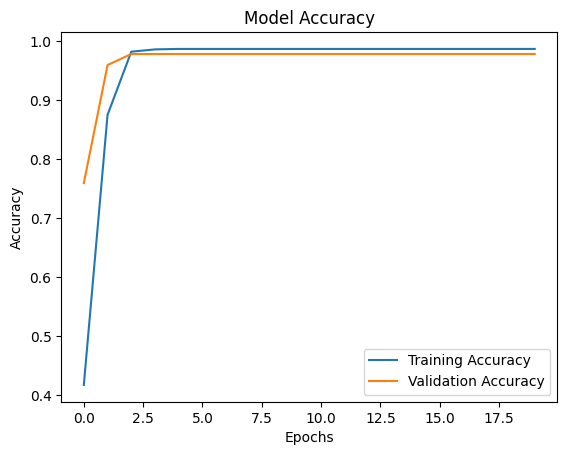

In [127]:
# Plotting training and validation accuracy

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

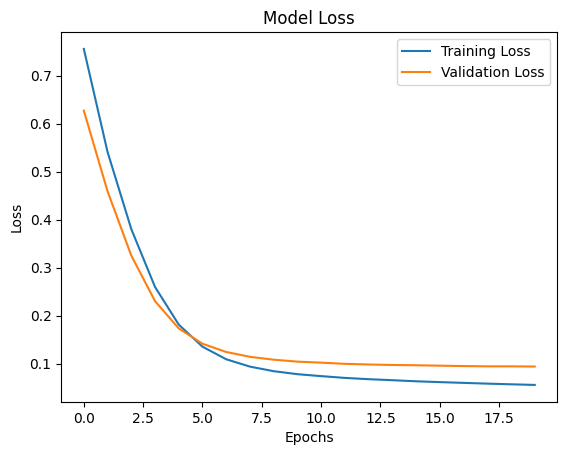

In [128]:
# Plotting training and validation loss

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [129]:
# Predicting values on testing data

y_pred = model.predict(X_test)

# Converting probabilities into binary values

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


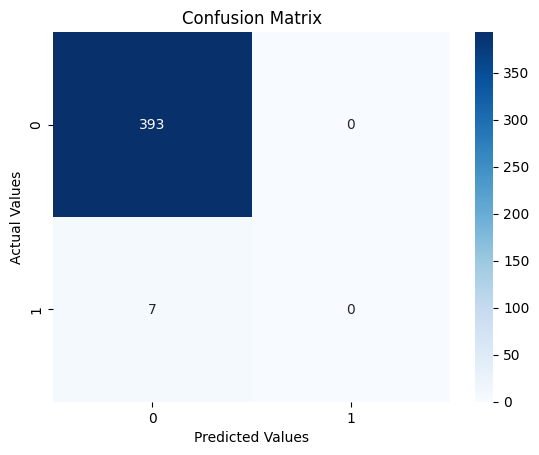

In [130]:
# Importing confusion matrix

from sklearn.metrics import confusion_matrix

# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Values")

plt.ylabel("Actual Values")

plt.show()

In [131]:
# Importing classification report

from sklearn.metrics import classification_report

# Printing classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Interpretation**:

The neural network model was trained and evaluated successfully on the customer churn dataset. The model achieved an overall testing accuracy of approximately 98%, indicating strong performance on the majority class.

From the classification report, class 0 (non-churn customers) achieved very high precision, recall, and F1-score values, showing that the model correctly identified most non-churn customers.

However, class 1 (churn customers) received very low precision, recall, and F1-score values. This happened because the dataset is highly imbalanced, with very few churn cases compared to non-churn cases. As a result, the model became biased toward predicting the majority class.

The confusion matrix and classification report indicate that although overall accuracy is high, the model struggles to correctly predict churn customers. Therefore, evaluation metrics such as precision, recall, and F1-score are important in addition to accuracy when working with imbalanced datasets.

**Task 5: Hyperparameter Experimentation**

In [132]:
# Importing optimizer

from tensorflow.keras.optimizers import Adam

In [ ]:
# Experiment 1:
# 1 hidden layer with 16 neurons

model1 = Sequential()

model1.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

model1.add(Dense(1, activation='sigmoid'))

# Compiling model

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training model

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluating model

loss1, accuracy1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", accuracy1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Experiment 2:
# 2 hidden layers with 32 and 16 neurons

model2 = Sequential()

model2.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model2.add(Dense(16, activation='relu'))

model2.add(Dense(1, activation='sigmoid'))

# Compiling model

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training model

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluating model

loss2, accuracy2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", accuracy2)

In [ ]:
# Experiment 3:
# Different activation function and batch size

model3 = Sequential()

model3.add(Dense(64, activation='tanh', input_shape=(X_train.shape[1],)))

model3.add(Dense(32, activation='tanh'))

model3.add(Dense(1, activation='sigmoid'))

# Compiling model

model3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Training model

history3 = model3.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

# Evaluating model

loss3, accuracy3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", accuracy3)

In [ ]:
# Creating comparison table for all experiments

comparison_table = pd.DataFrame({

    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],

    'Hidden Layers': [1, 2, 2],

    'Neurons': ['16', '32,16', '64,32'],

    'Activation Function': ['ReLU', 'ReLU', 'Tanh'],

    'Learning Rate': [0.001, 0.001, 0.01],

    'Batch Size': [32, 32, 64],

    'Epochs': [20, 30, 25],

    'Test Accuracy': [accuracy1, accuracy2, accuracy3]

})

# Displaying comparison table

comparison_table

In [ ]:
# Saving comparison table as CSV file

comparison_table.to_csv("model_comparison_table.csv", index=False)

**Observation**:

Three different neural network experiments were performed by changing hyperparameters such as hidden layers, number of neurons, activation functions, learning rate, batch size, and number of epochs.

Experiment 1 used one hidden layer with 16 neurons and achieved a testing accuracy of 98.25%.

Experiment 2 used two hidden layers with 32 and 16 neurons along with ReLU activation and achieved the highest testing accuracy of 98.50%. This indicates that increasing hidden layers and neurons improved the model’s learning performance.

Experiment 3 used two hidden layers with 64 and 32 neurons, Tanh activation function, a higher learning rate of 0.010, and batch size of 64. This model achieved 98.00% testing accuracy.

The comparison table shows that different hyperparameter configurations affect model performance and training behavior. Experiment 2 provided the best balance between model complexity and accuracy for this dataset.

**Task 6: Final Reflection**

**Final Reflection**:

In this neural network model, weights and biases played a very important role during training. Weights basically help the model understand which input features are more important for prediction, while biases help in adjusting the output and improving learning flexibility. During each training step, these values keep updating through backpropagation so that the model can reduce error and improve prediction accuracy.

Activation functions are also very necessary in neural networks because they help the model learn complex and non-linear patterns from the dataset. Without activation functions, the neural network would behave like a simple linear model and would not be able to capture deeper relationships between customer features and churn behavior. In this project, ReLU activation was used in hidden layers because it trains faster and performs well, while Sigmoid was used in the output layer since the target variable was binary (0 and 1).

The learning rate controls how fast or slow the model learns. If the learning rate becomes too high, the model may skip important learning points and training can become unstable. On the other side, if the learning rate is too low, the model takes a very long time to learn and training becomes slow.

From the results and classification report, the model showed slight overfitting and class imbalance issues. The overall accuracy was high because most customers belonged to the non-churn category, but the model struggled to correctly predict churn customers. This can be seen from the low recall and F1-score for class 1 in the classification report. So even though the accuracy looked very good, other evaluation metrics were also important to properly understand the real model performance.